<a href="https://colab.research.google.com/github/kaushikpatriot/ML-Projects/blob/main/Least_Square_%26_Perceptron_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Background
We will implement the least square classifier from scratch in this colab

A few points to recall from the theory
* Least squares method is used for estimating parameters of the Discriminant function from the given training data
* Least square classification adapts linear regression model  for classigication
  * It uses the **least square error** for the calculate the loss
  * It uses **normal equation** and **gradient descent** to estimate the parameters or weight vector
* Since it is a classification algorithm, we would use classification related evaluation metrics such as precison, recall, F1, AUC ROC/PR, and accuracy

Additionally note that:
* We make use of polynomial feature transformation to obtain new features and then use that representation to learn non-linear decision boundaries between classes

$y = w_0 + w^T \phi(x)$
where $\phi(x)$ is a polynomial feature transformation

* We can tackles issues of overfitting by using ridge or lasso regularization just like linear regression models


In [ ]:
# Import libraries
from IPython.display import display, Math, Latex #Imported for proper rendering of latex in Colab
import numpy as np

#Import for generating plots
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
# Generating combination of polynomials
import itertools
import functools

def get_combinations(x, degree):
  return itertools.combinations_with_replacement(x,degree)

def compute_new_features(items):
  return functools.reduce(lambda x, y: x*y, items)

In [ ]:
import numpy as np
import itertools
import functools

def polynomial_transform(x, degree, logging = False):
  # Converts to feature matrix
  if x.ndim == 1:
    x = x[:,None]

  x_t = x.transpose() # Transposes the feature matrix
  features = [np.ones(len(x))] # Populates 1s as the first feature for each example

  if logging:
    print ("Input:", x)

  for degree in range(1,degree+1):
    for items in get_combinations(x_t, degree):
      features.append(compute_new_features(items))
      if logging:
        print(items,":",compute_new_features(items))

  if logging:
    print(np.asarray(features).transpose())
  return np.asarray(features).transpose()



##Label Encoding
Since the output $y$ is a discrete quantity, we use one-hot encoding to represent label. For a binary classification
* The label $0$ is represented as $[1,0]$
* The label $1$ is represented as $[0,1]$

The same scheme is extended to **multi-class** setting. In general for a $k$ class set up, we use one-hot encoding in $k$ component vector $[y_1, y_2, y_3....y_k]$. For label $l <= r <= k, y_r$ would be 1 and other components would be 0

* The label 0 is represented with $[1,0,0]$
* The label 1 is represented with $[0,1,0]$
* The label 2 is represented with $[0,0,1]$

In the following class, we implement, LabelTransformer, that converts discrete label into one-hot encoding,


In [ ]:
class LabelTransformer(object):
  '''
  Label encoder decoder
  Attributes:
  n_classes: int
  number of classes : k
  '''

  def __init__(self, n_classes:int=None):
    self.n_classes = n_classes

  @property
  def n_classes(self):
    return self.__n_classes

  @n_classes.setter
  def n_classes(self, K):
    self.__n_classes = K
    self.__encoder = None if K is None else np.eye(K)

  @property
  def encoder(self):
    return self.__encoder

  def encode(self, class_indices:np.ndarray):
    '''
    encode class index into one of k code
    Parameters:
    class_indices: (N,) np.ndarray
        non-negative class index
        elements must be integer in (0, n_classes)
    Returns:
    (N, K) np.ndarray
      one-of-k encoding of input
     '''
    if self.n_classes is None:
      self.n_classes = np.max(class_indices) + 1

    return self.encoder[class_indices]

  def decode(self, onehot:np.ndarray):
    """
    decode one-of-k code into a class index
    Parameters:
    onehot: (N,K) np.ndarray
        one-of-k code

    Returns:
    (N,) np.ndarray
        class index
    """
    return np.argmax(onehot, axis=1)

In [ ]:
binary_labels = LabelTransformer().encode(np.array([1,0,1,0]))
binary_labels

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.]])

In [ ]:
multiclass_labels = LabelTransformer(3).encode(np.array([1,0,1,2]))
multiclass_labels

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

##Least Square Classification Implementation

###Training Data
This representation of label has an impact on the learning set up. Now we have

* A feature matrix $X$ of shape $(n,m)$ where $n$ is the number of examples, $m$ is the number of features
* A label matrix $Y$ of shape $(n,k)$ where k is the number of class labels. Note that this set up is similar to multiple regression

###Model
The label matrix is obtained by matrix multiplication of feature matrix and weight matrix. After adding the dummy feature to the feature matrix, its shape becomes $n \times {(m+1)}$

$Y_{n \times k} = X_{n \times {(m+1)}} W_{(m+1) \times k}$  

There is one weight vector per output. Hence the total number of parameters to be estimated = $(m+1) \times k$

###Loss function
This results into the following loss matrix of shape $(k,k)$

$ J(W) = \frac {1}{2} (Y_{n \times k} - X_{n \times {(m+1)}} W_{(m+1 \times k)})^T (Y_{n \times k} - X_{n \times {(m+1)}} W_{(m+1 \times k)}) + \frac {\lambda}{2} W^TW$
$ = \frac {1}{2}(E^T)_{(k \times n)}E_{(n \times k)} + (\frac{\lambda}{2} W^TW)$

###Normal Equation
There is almost no code change needed in fit function thats uses normal equation method for parameter or weight vector estimation

$W = (X^TX + \lambda I)^{-1}X^TY$

###Iterative optimisation (GD, MBGD & SD)
The gradient calculation ***(calculate_gradient)*** for iterative optimization is performed as follows:

$\frac {\partial J(W)} {\partial W} = X^T(XW-Y) + \lambda W $

and the new value of W is calculated in the vectorized form:

$W^{new} := W^{old} - \alpha \frac {\partial J(W)} {\partial W}$

###Inference
The predict function for this classification set up is expected to return a discrete quantity (unlike a real number in regression set up).
* We return the class label with the largest value of linear combination of features among all classes

### Works for multi-class classification
All other functions are adapted from ridge regression and multiple regression colabs
This implementation is generic enough to work on multi class set up and also polynomial transformation followed by the least squares classification.


In [ ]:
class LeastSquareClassification(object):
  '''
  LSC model
  y = np.where(X@w >= 0, 1, 0)
  X : A feature matrix
  w : Weight vector
  y : label vector
  '''

  def __init__(self):
    self.t0 = 20
    self.t1 = 1000

  def predict(self, X:np.ndarray) -> np.ndarray:
    '''
    Prediction of output label for a given input

    Args:
      X: Feature matrix for given inputs

    Returns:
      y: Output label vector as predicted by the given model
    '''
    # Test the shapes are compatible
    assert X.shape[-1] == self.w.shape[0], f"X shape {X.shape} and w shape {self.w.shape} are not compatible"
    return np.argmax(X @self.w, axis = -1)

  def predict_internal(self,X:np.ndarray) -> np.ndarray:
    '''
    Prediction of output label for a given input

    Args:
    X: Feature matrix for given inputs

    Returns:
    y: OUtput label vector encoded in label encoder format

    '''
    assert X.shape[-1]==self.w.shape[0] , f"X shape {X.shape} and w shape {self.w.shape} are not compatible"
    return X @self.w






In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
np.random.seed(0)
x1 = np.random.normal(2,2, size=100).reshape(-1,2)
x2 = np.random.normal(10,2, size=100).reshape(-1,2)

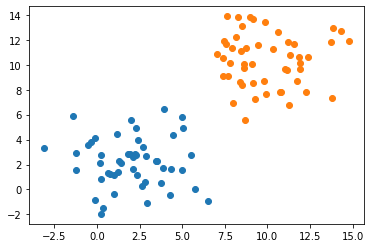

In [ ]:
plt.scatter(x1[:,0], x1[:, 1])
plt.scatter(x2[:,0], x2[:, 1])
plt.show()

In [ ]:
y1 = np.zeros(x1.shape[0])
y2 = np.ones(x2.shape[0])

x = np.concatenate((x1,x2))
y = np.concatenate((y1,y2))

x = np.column_stack((np.ones(x.shape[0]),x))
np.random.seed(1)
a = np.random.permutation(100)
X = x[a]
Y = y[a].astype(np.int64)

In [ ]:
k = np.max(Y) + 1
I = np.eye(k)
Y_encoded = I[Y].astype(np.int64)

In [ ]:
X_train = X[:80]
X_test = X[80:]
y_train = Y_encoded[:80]
y_test = Y_encoded[80:]
print(X_train.shape,X_test.shape,y_train.shape, y_test.shape)


(80, 3) (20, 3) (80, 2) (20, 2)


###Model

In [ ]:
def predict(X, w):
  z = X @ w
  return np.argmax(z, axis = 1)

w = np.random.rand(X_train.shape[1], y_train.shape[1])
print(w)
predict(X_train, w)


[[0.04534573 0.13996612]
 [0.79240359 0.02980136]
 [0.88312548 0.54078819]]


array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
def loss(X, y, w):
  e = y - predict(X,w)
  loss = 0.5*np.trace(np.transpose(e) @ e)
  return loss

loss(X_train, y_train, w)

7163.307041271227

In [ ]:
def fit(X, y):
  w = np.linalg.pinv(np.transpose(X)@X) @ np.transpose(X) @ y
  return w

w_new = fit(X_train, y_train)

loss(X_train, y_train, w_new)

2.062514844824708

In [ ]:
predict(X_train, w_new)

array([1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0])

In [ ]:
def grad(X, y, w):
  dFdW = np.transpose(X) @ (X@w - y)
  return dFdW

def update_weights(X, y, w, lr):
  w_new = w - lr* grad(X, y, w)
  return w_new

def gd(X, y, num_epochs, lr):
  w = np.zeros((X.shape[1], y.shape[1]))
  w_all = []
  error_all = []
  w_all.append(w.copy())
  for i in range (num_epochs):
    dfdw = grad(X, y, w)
    w = update_weights(X, y, w, lr)
    w_all.append(w.copy())
  return w


w_latest = gd(X_train, y_train, 100000, 1e-5)
loss(X_train, y_train, w_latest)

predict(X_train, w_latest)

array([1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0])

###Perceptron

In [ ]:
import numpy as np
# Generate Data set
x = np.linspace(0.01,1,50)
x = np.column_stack((np.ones(x.shape), x))

y = np.random.randint(2,size = 50)
y = np.where(y==0,-1,1)

w = np.random.randint(3,size=2)

epochs = 5
w_all = []
w_all.append(w)
errors_all = []

for i in range (epochs):
  errors = 0
  for xi, target in zip (x,y):
    z = xi @ w
    y_hat = np.where(z >= 0, 1, -1)
    w = w + (target - y_hat) * xi
    errors += max(-1*y_hat*target,0)
  errors_all.append(errors)
  print(w)
  w_all.append(w)
history = np.asarray(w_all)
history

[0.         3.05061224]
[-2.          2.18204082]
[0.         3.25265306]
[-2.          2.54571429]
[0.         3.61632653]


array([[ 0.        ,  2.        ],
       [ 0.        ,  3.05061224],
       [-2.        ,  2.18204082],
       [ 0.        ,  3.25265306],
       [-2.        ,  2.54571429],
       [ 0.        ,  3.61632653]])

##Least Squares

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Generate Data Set
def gen_data_set(n_samples):
  x1 = np.random.normal(2, 1, n_samples).reshape(-1,2)
  x2 = np.random.normal(-2,0.95, n_samples).reshape(-1,2)
  y1 = np.zeros(x1.shape[0]).astype(int)
  y2 = np.ones(x2.shape[0]).astype(int)
  x = np.concatenate((x1,x2),axis=0)
  y = np.concatenate((y1,y2),axis=0)
  x = np.column_stack((np.ones(x.shape[0]),x))
  return x,y,x1,x2,y1,y2

x,y,x1, x2, y1, y2 = gen_data_set(100)
x.shape, y.shape, x1.shape, x2.shape, y1.shape, y2.shape


((100, 3), (100,), (50, 2), (50, 2), (50,), (50,))

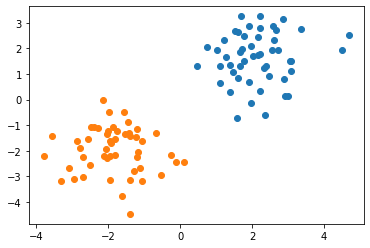

In [ ]:
#Plot features
plt.scatter(x1[:,0], x1[:,1])
plt.scatter(x2[:,0], x2[:,1])

In [ ]:
#Train and Test Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state = 42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((80, 3), (20, 3), (80,), (20,))

In [ ]:
#One hot encoding
def one_hot_encode(y):
  k = len(np.unique(y))
  eye = np.eye(k)
  y_encode = eye[y]
  return k, y_encode

k, y_encode = one_hot_encode(y_train)

In [ ]:
#Predict, Loss
w = np.zeros((x_train.shape[1],k))
def predict_internal(x,w):
  return x @ w

def predict(x,w):
  return np.argmax(x @ w,axis=-1)

predict(x_train, w)

def loss(x,w,y):
  e = predict_internal(x,w) - y
  loss = 0.5*np.trace(e.T @ e)
  return loss

def fit(x,w,y):
  return np.linalg.solve(x.T@x, x.T@y)

w = fit(x_train,w,y_encode)
loss = loss(x_train,w,y_encode)
w, loss

(array([[ 0.48371064,  0.51628936],
        [ 0.09051337, -0.09051337],
        [ 0.13691994, -0.13691994]]), 2.8563934687736108)

##Perceptron classifier

In [ ]:
def predict(x,w):
  z = x @ w
  return np.where(z>=0,1,-1)

def loss(x,w,y):
  z = predict(x,w)
  loss = np.sum(np.maximum(-1*z*y,0))
  return loss

def perceptron(x,y, epochs, lr):
  w = np.zeros(x.shape[1])
  err = []
  for i in range(epochs):
    for xi, yi in zip(x,y):
      z = xi @ w
      y_hat = np.where(z >= 0, 1,-1)
      w = w + lr*(y_hat-yi)*xi
    err.append(loss(x,w,y))
    if (i%10==0):
      print(w)
  return w, err

w, err = perceptron(x_train,y_train,100,0.01)
loss(x_train,w,y_train)

[-0.42        2.28851191  2.14620748]
[-5.02       25.76048908 24.77191466]
[-9.62       49.23246624 47.39762185]
[-14.22        72.7044434   70.02332903]
[-18.82        96.17642056  92.64903622]
[-23.42       119.64839773 115.27474341]
[-28.02       143.12037489 137.90045059]
[-32.62       166.59235205 160.52615778]
[-37.22       190.06432921 183.15186496]
[-41.82       213.53630638 205.77757215]


42

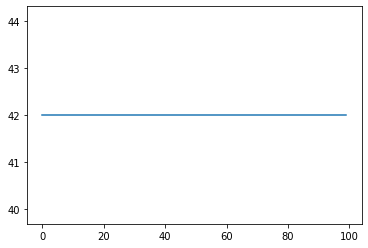

In [ ]:
plt.plot(np.arange(100),err)